# ConvNeXt Architecture Analysis

This notebook provides a comprehensive analysis of all ConvNeXt model variants, including:
- Parameter counts for each model size
- Stage-wise neuron counts and architecture details
- Resolution and channel progression through each stage
- Comparative visualizations across model variants

ConvNeXt models analyzed: Tiny, Small, Base, Large, and XLarge

## 1. Install and Import Required Libraries

In [1]:
# Install required packages if not already installed
import subprocess
import sys

def install_package(package):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    except subprocess.CalledProcessError:
        print(f"Failed to install {package}")

# Install timm for comprehensive model support
try:
    import timm
except ImportError:
    print("Installing timm...")
    install_package("timm")
    import timm

print("✓ All packages installed successfully")

Installing timm...
  Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 13.2 MB/s eta 0:00:00
Using cached hf_xet-1.2.0-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (507 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [timm]6/7 [timm]ngface_hub]
✓ All packages installed successfully


In [4]:
# Import all required libraries
import torch
import torch.nn as nn
import torchvision
from torchvision import models
import timm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import OrderedDict
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"TIMM version: {timm.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.7.1+cu126
Torchvision version: 0.22.1+cu126
TIMM version: 1.0.24
Device: CUDA


## 2. Download ConvNeXt Models

In [5]:
# Define all ConvNeXt model variants to analyze
convnext_variants = {
    'ConvNeXt-Tiny': 'convnext_tiny.fb_in22k',
    'ConvNeXt-Small': 'convnext_small.fb_in22k', 
    'ConvNeXt-Base': 'convnext_base.fb_in22k',
    'ConvNeXt-Large': 'convnext_large.fb_in22k',
    'ConvNeXt-XLarge': 'convnext_xlarge.fb_in22k'
}

# Alternative: Use torchvision models if timm is not available
torchvision_variants = {
    'ConvNeXt-Tiny': 'convnext_tiny',
    'ConvNeXt-Small': 'convnext_small',
    'ConvNeXt-Base': 'convnext_base', 
    'ConvNeXt-Large': 'convnext_large'
}

print("Available ConvNeXt variants:")
for name, model_id in convnext_variants.items():
    print(f"  - {name}: {model_id}")
print("\nStarting model downloads...")

Available ConvNeXt variants:
  - ConvNeXt-Tiny: convnext_tiny.fb_in22k
  - ConvNeXt-Small: convnext_small.fb_in22k
  - ConvNeXt-Base: convnext_base.fb_in22k
  - ConvNeXt-Large: convnext_large.fb_in22k
  - ConvNeXt-XLarge: convnext_xlarge.fb_in22k

Starting model downloads...


In [6]:
# Load all ConvNeXt models
models_dict = OrderedDict()

for name, model_id in convnext_variants.items():
    try:
        print(f"Loading {name}...")
        model = timm.create_model(model_id, pretrained=True)
        model.eval()
        models_dict[name] = model
        print(f"✓ {name} loaded successfully")
    except Exception as e:
        print(f"✗ Failed to load {name} from timm: {e}")
        # Try torchvision as fallback
        if name in torchvision_variants:
            try:
                tv_model_name = torchvision_variants[name]
                model = getattr(models, tv_model_name)(weights='DEFAULT')
                model.eval()
                models_dict[name] = model
                print(f"✓ {name} loaded from torchvision")
            except Exception as e2:
                print(f"✗ Also failed to load {name} from torchvision: {e2}")

print(f"\n{len(models_dict)} models loaded successfully:")
for name in models_dict.keys():
    print(f"  - {name}")

Loading ConvNeXt-Tiny...


model.safetensors:   0%|          | 0.00/178M [00:00<?, ?B/s]

✓ ConvNeXt-Tiny loaded successfully
Loading ConvNeXt-Small...


model.safetensors:   0%|          | 0.00/265M [00:00<?, ?B/s]

✓ ConvNeXt-Small loaded successfully
Loading ConvNeXt-Base...


...

✓ ConvNeXt-Base loaded successfully
Loading ConvNeXt-Large...


model.safetensors:   0%|          | 0.00/919M [00:00<?, ?B/s]

✓ ConvNeXt-Large loaded successfully
Loading ConvNeXt-XLarge...


model.safetensors:   0%|          | 0.00/1.57G [00:00<?, ?B/s]

✓ ConvNeXt-XLarge loaded successfully

5 models loaded successfully:
  - ConvNeXt-Tiny
  - ConvNeXt-Small
  - ConvNeXt-Base
  - ConvNeXt-Large
  - ConvNeXt-XLarge


## 3. Extract Model Architecture Information

In [7]:
def analyze_model_architecture(model, model_name):
    """Extract detailed architecture information from a ConvNeXt model"""
    
    # Count total parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Get model structure info
    model_info = {
        'model_name': model_name,
        'total_params': total_params,
        'trainable_params': trainable_params,
        'stages': []
    }
    
    # Input resolution (standard ConvNeXt input)
    input_size = 224
    current_resolution = input_size
    
    # Analyze each stage
    if hasattr(model, 'features') or hasattr(model, 'stages'):
        # For torchvision models
        if hasattr(model, 'features'):
            stages = model.features
        else:
            stages = model.stages
            
        for i, stage in enumerate(stages):
            stage_params = sum(p.numel() for p in stage.parameters())
            
            # Estimate output channels and resolution for each stage
            if i == 0:
                # Stem/first stage - usually downsample by 4
                current_resolution = input_size // 4
                out_channels = 96  # ConvNeXt typically starts with 96 channels
            else:
                # Each subsequent stage typically halves resolution and doubles channels
                current_resolution = current_resolution // 2
                out_channels = out_channels * 2
            
            # Calculate neurons (approximate based on feature map size)
            neurons = current_resolution * current_resolution * out_channels
            
            stage_info = {
                'stage_idx': i,
                'stage_name': f'Stage_{i}',
                'parameters': stage_params,
                'neurons': neurons,
                'resolution': current_resolution,
                'channels': out_channels
            }
            
            model_info['stages'].append(stage_info)
    
    return model_info

# Test with one model first
if models_dict:
    test_model_name = list(models_dict.keys())[0]
    test_model = models_dict[test_model_name]
    test_info = analyze_model_architecture(test_model, test_model_name)
    print(f"Test analysis for {test_model_name}:")
    print(f"Total parameters: {test_info['total_params']:,}")
    print(f"Number of stages: {len(test_info['stages'])}")
else:
    print("No models loaded for analysis")

Test analysis for ConvNeXt-Tiny:
Total parameters: 44,615,857
Number of stages: 4


In [8]:
def get_accurate_stage_info(model, input_tensor):
    """Get accurate stage information by forward pass analysis"""
    
    activations = []
    hooks = []
    
    def hook_fn(name):
        def hook(module, input, output):
            if isinstance(output, torch.Tensor):
                activations.append({
                    'name': name,
                    'shape': output.shape,
                    'neurons': output.numel()
                })
        return hook
    
    # Register hooks for major components
    stage_modules = []
    
    # Find stage-like modules
    for name, module in model.named_modules():
        if 'stage' in name.lower() or 'features' in name.lower():
            if len(list(module.children())) > 0:  # Only hook container modules
                hooks.append(module.register_forward_hook(hook_fn(name)))
                stage_modules.append((name, module))
    
    # Forward pass
    with torch.no_grad():
        _ = model(input_tensor)
    
    # Clean up hooks
    for hook in hooks:
        hook.remove()
    
    return activations, stage_modules

# Test accurate analysis with a small input
if models_dict:
    print("Analyzing model architectures with forward pass...")
    test_input = torch.randn(1, 3, 224, 224)
    
    for name, model in list(models_dict.items())[:2]:  # Test first 2 models
        print(f"\nAnalyzing {name}...")
        try:
            activations, stage_modules = get_accurate_stage_info(model, test_input)
            print(f"Found {len(activations)} activation points")
            print(f"Stage modules: {len(stage_modules)}")
            
            for i, act in enumerate(activations[:5]):  # Show first 5
                print(f"  {act['name']}: {act['shape']} ({act['neurons']:,} neurons)")
        except Exception as e:
            print(f"Error analyzing {name}: {e}")
else:
    print("No models available for analysis")

Analyzing model architectures with forward pass...

Analyzing ConvNeXt-Tiny...
Found 48 activation points
Stage modules: 48
  stages.0.blocks.0.mlp: torch.Size([1, 56, 56, 96]) (301,056 neurons)
  stages.0.blocks.0: torch.Size([1, 96, 56, 56]) (301,056 neurons)
  stages.0.blocks.1.mlp: torch.Size([1, 56, 56, 96]) (301,056 neurons)
  stages.0.blocks.1: torch.Size([1, 96, 56, 56]) (301,056 neurons)
  stages.0.blocks.2.mlp: torch.Size([1, 56, 56, 96]) (301,056 neurons)

Analyzing ConvNeXt-Small...
Found 84 activation points
Stage modules: 84
  stages.0.blocks.0.mlp: torch.Size([1, 56, 56, 96]) (301,056 neurons)
  stages.0.blocks.0: torch.Size([1, 96, 56, 56]) (301,056 neurons)
  stages.0.blocks.1.mlp: torch.Size([1, 56, 56, 96]) (301,056 neurons)
  stages.0.blocks.1: torch.Size([1, 96, 56, 56]) (301,056 neurons)
  stages.0.blocks.2.mlp: torch.Size([1, 56, 56, 96]) (301,056 neurons)


## 4. Calculate Parameters and Neurons per Stage

In [12]:
def detailed_convnext_analysis(model, model_name):
    """Comprehensive analysis of ConvNeXt architecture"""
    
    total_params = sum(p.numel() for p in model.parameters())
    
    # ConvNeXt specific analysis
    analysis = {
        'model_name': model_name,
        'total_params': total_params,
        'stages': []
    }
    
    # Standard ConvNeXt architecture assumptions
    input_size = 224
    
    # Define stage configurations for different ConvNeXt variants
    stage_configs = {
        'ConvNeXt-Tiny': [(96, 56), (192, 28), (384, 14), (768, 7)],
        'ConvNeXt-Small': [(96, 56), (192, 28), (384, 14), (768, 7)],
        'ConvNeXt-Base': [(128, 56), (256, 28), (512, 14), (1024, 7)],
        'ConvNeXt-Large': [(192, 56), (384, 28), (768, 14), (1536, 7)],
        'ConvNeXt-XLarge': [(256, 56), (512, 28), (1024, 14), (2048, 7)]
    }
    
    # Get stage configuration
    if model_name in stage_configs:
        configs = stage_configs[model_name]
    else:
        # Default configuration
        configs = [(96, 56), (192, 28), (384, 14), (768, 7)]
    
    # Analyze each stage
    stage_param_counts = []
    
    # Try to get actual stage modules
    if hasattr(model, 'features'):
        stages = list(model.features)
    elif hasattr(model, 'stages'):
        stages = list(model.stages)
    else:
        # Find stage-like modules
        stages = []
        for name, module in model.named_children():
            if 'stage' in name.lower() or 'features' in name.lower():
                stages.append(module)
    
    # Calculate parameters per stage
    if stages:
        for i, stage in enumerate(stages):
            stage_params = sum(p.numel() for p in stage.parameters())
            stage_param_counts.append(stage_params)
    else:
        # Estimate based on total parameters
        stage_param_counts = [total_params // 4] * 4
    
    # Create detailed stage analysis
    for i, (channels, resolution) in enumerate(configs):
        neurons = channels * resolution * resolution
        
        stage_info = {
            'stage_idx': i + 1,
            'stage_name': f'Stage {i + 1}',
            'parameters': stage_param_counts[i] if i < len(stage_param_counts) else 0,
            'neurons': neurons,
            'resolution': resolution,
            'channels': channels
        }
        
        analysis['stages'].append(stage_info)
    
    return analysis

# Analyze all models
all_analyses = OrderedDict()

print("Performing comprehensive analysis of all models...\n")

for model_name, model in models_dict.items():
    print(f"Analyzing {model_name}...")
    analysis = detailed_convnext_analysis(model, model_name)
    all_analyses[model_name] = analysis
    
    print(f"  Total parameters: {analysis['total_params']:,}")
    print(f"  Number of stages: {len(analysis['stages'])}")
    stage_params = [f"{s['parameters']:,}" for s in analysis['stages']]
    print(f"  Stage parameters: {stage_params}")
    print()

print(f"Analysis complete for {len(all_analyses)} models!")

Performing comprehensive analysis of all models...

Analyzing ConvNeXt-Tiny...
  Total parameters: 44,615,857
  Number of stages: 4
  Stage parameters: ['237,888', '992,256', '11,112,960', '15,470,592']

Analyzing ConvNeXt-Small...
  Total parameters: 66,250,417
  Number of stages: 4
  Stage parameters: ['237,888', '992,256', '32,747,520', '15,470,592']

Analyzing ConvNeXt-Base...
  Total parameters: 109,953,489
  Number of stages: 4
  Stage parameters: ['415,488', '1,748,992', '57,950,208', '27,443,200']

Analyzing ConvNeXt-Large...
  Total parameters: 229,799,953
  Number of stages: 4
  Stage parameters: ['918,144', '3,901,440', '129,785,856', '61,612,032']

Analyzing ConvNeXt-XLarge...
  Total parameters: 392,900,177
  Number of stages: 4
  Stage parameters: ['1,617,408', '6,905,856', '230,195,200', '109,412,352']

Analysis complete for 5 models!


## 5. Analyze Resolution and Channel Progression

In [13]:
# Analyze resolution and channel progression across stages
print("Resolution and Channel Progression Analysis")
print("=" * 50)

for model_name, analysis in all_analyses.items():
    print(f"\n{model_name}:")
    print(f"{'Stage':<8} {'Resolution':<12} {'Channels':<10} {'Neurons':<15} {'Parameters':<12}")
    print("-" * 65)
    
    for stage in analysis['stages']:
        print(f"{stage['stage_name']:<8} "
              f"{stage['resolution']}x{stage['resolution']:<9} "
              f"{stage['channels']:<10,} "
              f"{stage['neurons']:<15,} "
              f"{stage['parameters']:<12,}")
    
    total_neurons = sum(s['neurons'] for s in analysis['stages'])
    print(f"\nTotal neurons across all stages: {total_neurons:,}")
    print(f"Total parameters: {analysis['total_params']:,}")

# Calculate progression ratios
print("\n" + "=" * 70)
print("PROGRESSION ANALYSIS")
print("=" * 70)

for model_name, analysis in all_analyses.items():
    print(f"\n{model_name} - Channel and Resolution Progression:")
    stages = analysis['stages']
    
    for i in range(1, len(stages)):
        prev_stage = stages[i-1]
        curr_stage = stages[i]
        
        channel_ratio = curr_stage['channels'] / prev_stage['channels']
        resolution_ratio = curr_stage['resolution'] / prev_stage['resolution']
        neuron_ratio = curr_stage['neurons'] / prev_stage['neurons']
        
        print(f"  Stage {i} → {i+1}:")
        print(f"    Channels: {prev_stage['channels']} → {curr_stage['channels']} (×{channel_ratio:.1f})")
        print(f"    Resolution: {prev_stage['resolution']} → {curr_stage['resolution']} (×{resolution_ratio:.2f})")
        print(f"    Neurons: {prev_stage['neurons']:,} → {curr_stage['neurons']:,} (×{neuron_ratio:.2f})")
        print()

Resolution and Channel Progression Analysis

ConvNeXt-Tiny:
Stage    Resolution   Channels   Neurons         Parameters  
-----------------------------------------------------------------
Stage 1  56x56        96         301,056         237,888     
Stage 2  28x28        192        150,528         992,256     
Stage 3  14x14        384        75,264          11,112,960  
Stage 4  7x7         768        37,632          15,470,592  

Total neurons across all stages: 564,480
Total parameters: 44,615,857

ConvNeXt-Small:
Stage    Resolution   Channels   Neurons         Parameters  
-----------------------------------------------------------------
Stage 1  56x56        96         301,056         237,888     
Stage 2  28x28        192        150,528         992,256     
Stage 3  14x14        384        75,264          32,747,520  
Stage 4  7x7         768        37,632          15,470,592  

Total neurons across all stages: 564,480
Total parameters: 66,250,417

ConvNeXt-Base:
Stage    Resolu

## 6. Create Summary Table

In [14]:
# Create comprehensive summary tables

# 1. Model overview table
model_summary_data = []
for model_name, analysis in all_analyses.items():
    total_neurons = sum(s['neurons'] for s in analysis['stages'])
    model_summary_data.append({
        'Model': model_name,
        'Total Parameters': f"{analysis['total_params']:,}",
        'Total Neurons': f"{total_neurons:,}",
        'Stages': len(analysis['stages']),
        'Input Resolution': '224x224',
        'Final Channels': analysis['stages'][-1]['channels'] if analysis['stages'] else 'N/A'
    })

model_summary_df = pd.DataFrame(model_summary_data)
print("MODEL OVERVIEW SUMMARY")
print("=" * 80)
print(model_summary_df.to_string(index=False))
print()

# 2. Detailed stage-wise table
stage_summary_data = []
for model_name, analysis in all_analyses.items():
    for stage in analysis['stages']:
        stage_summary_data.append({
            'Model': model_name,
            'Stage': stage['stage_name'],
            'Resolution': f"{stage['resolution']}x{stage['resolution']}",
            'Channels': f"{stage['channels']:,}",
            'Neurons': f"{stage['neurons']:,}",
            'Parameters': f"{stage['parameters']:,}"
        })

stage_summary_df = pd.DataFrame(stage_summary_data)
print("DETAILED STAGE-WISE SUMMARY")
print("=" * 80)
print(stage_summary_df.to_string(index=False))
print()

# 3. Parameter distribution table
print("PARAMETER DISTRIBUTION BY STAGE")
print("=" * 60)
for model_name, analysis in all_analyses.items():
    total_params = analysis['total_params']
    print(f"\n{model_name} (Total: {total_params:,} parameters):")
    
    for stage in analysis['stages']:
        percentage = (stage['parameters'] / total_params) * 100 if total_params > 0 else 0
        print(f"  {stage['stage_name']}: {stage['parameters']:,} ({percentage:.1f}%)")

# Save summary tables
print(f"\nSummary tables created:")
print(f"- Model overview: {len(model_summary_df)} models")
print(f"- Stage details: {len(stage_summary_df)} stages total")

# Export to CSV for further analysis
model_summary_df.to_csv('/home/wanglab/PyTorch/ConvNeXT/convnext_model_summary.csv', index=False)
stage_summary_df.to_csv('/home/wanglab/PyTorch/ConvNeXT/convnext_stage_summary.csv', index=False)
print(f"✓ Summary tables exported to CSV files")

MODEL OVERVIEW SUMMARY
          Model Total Parameters Total Neurons  Stages Input Resolution  Final Channels
  ConvNeXt-Tiny       44,615,857       564,480       4          224x224             768
 ConvNeXt-Small       66,250,417       564,480       4          224x224             768
  ConvNeXt-Base      109,953,489       752,640       4          224x224            1024
 ConvNeXt-Large      229,799,953     1,128,960       4          224x224            1536
ConvNeXt-XLarge      392,900,177     1,505,280       4          224x224            2048

DETAILED STAGE-WISE SUMMARY
          Model   Stage Resolution Channels Neurons  Parameters
  ConvNeXt-Tiny Stage 1      56x56       96 301,056     237,888
  ConvNeXt-Tiny Stage 2      28x28      192 150,528     992,256
  ConvNeXt-Tiny Stage 3      14x14      384  75,264  11,112,960
  ConvNeXt-Tiny Stage 4        7x7      768  37,632  15,470,592
 ConvNeXt-Small Stage 1      56x56       96 301,056     237,888
 ConvNeXt-Small Stage 2      28x28  

## 7. Visualize Architecture Comparison

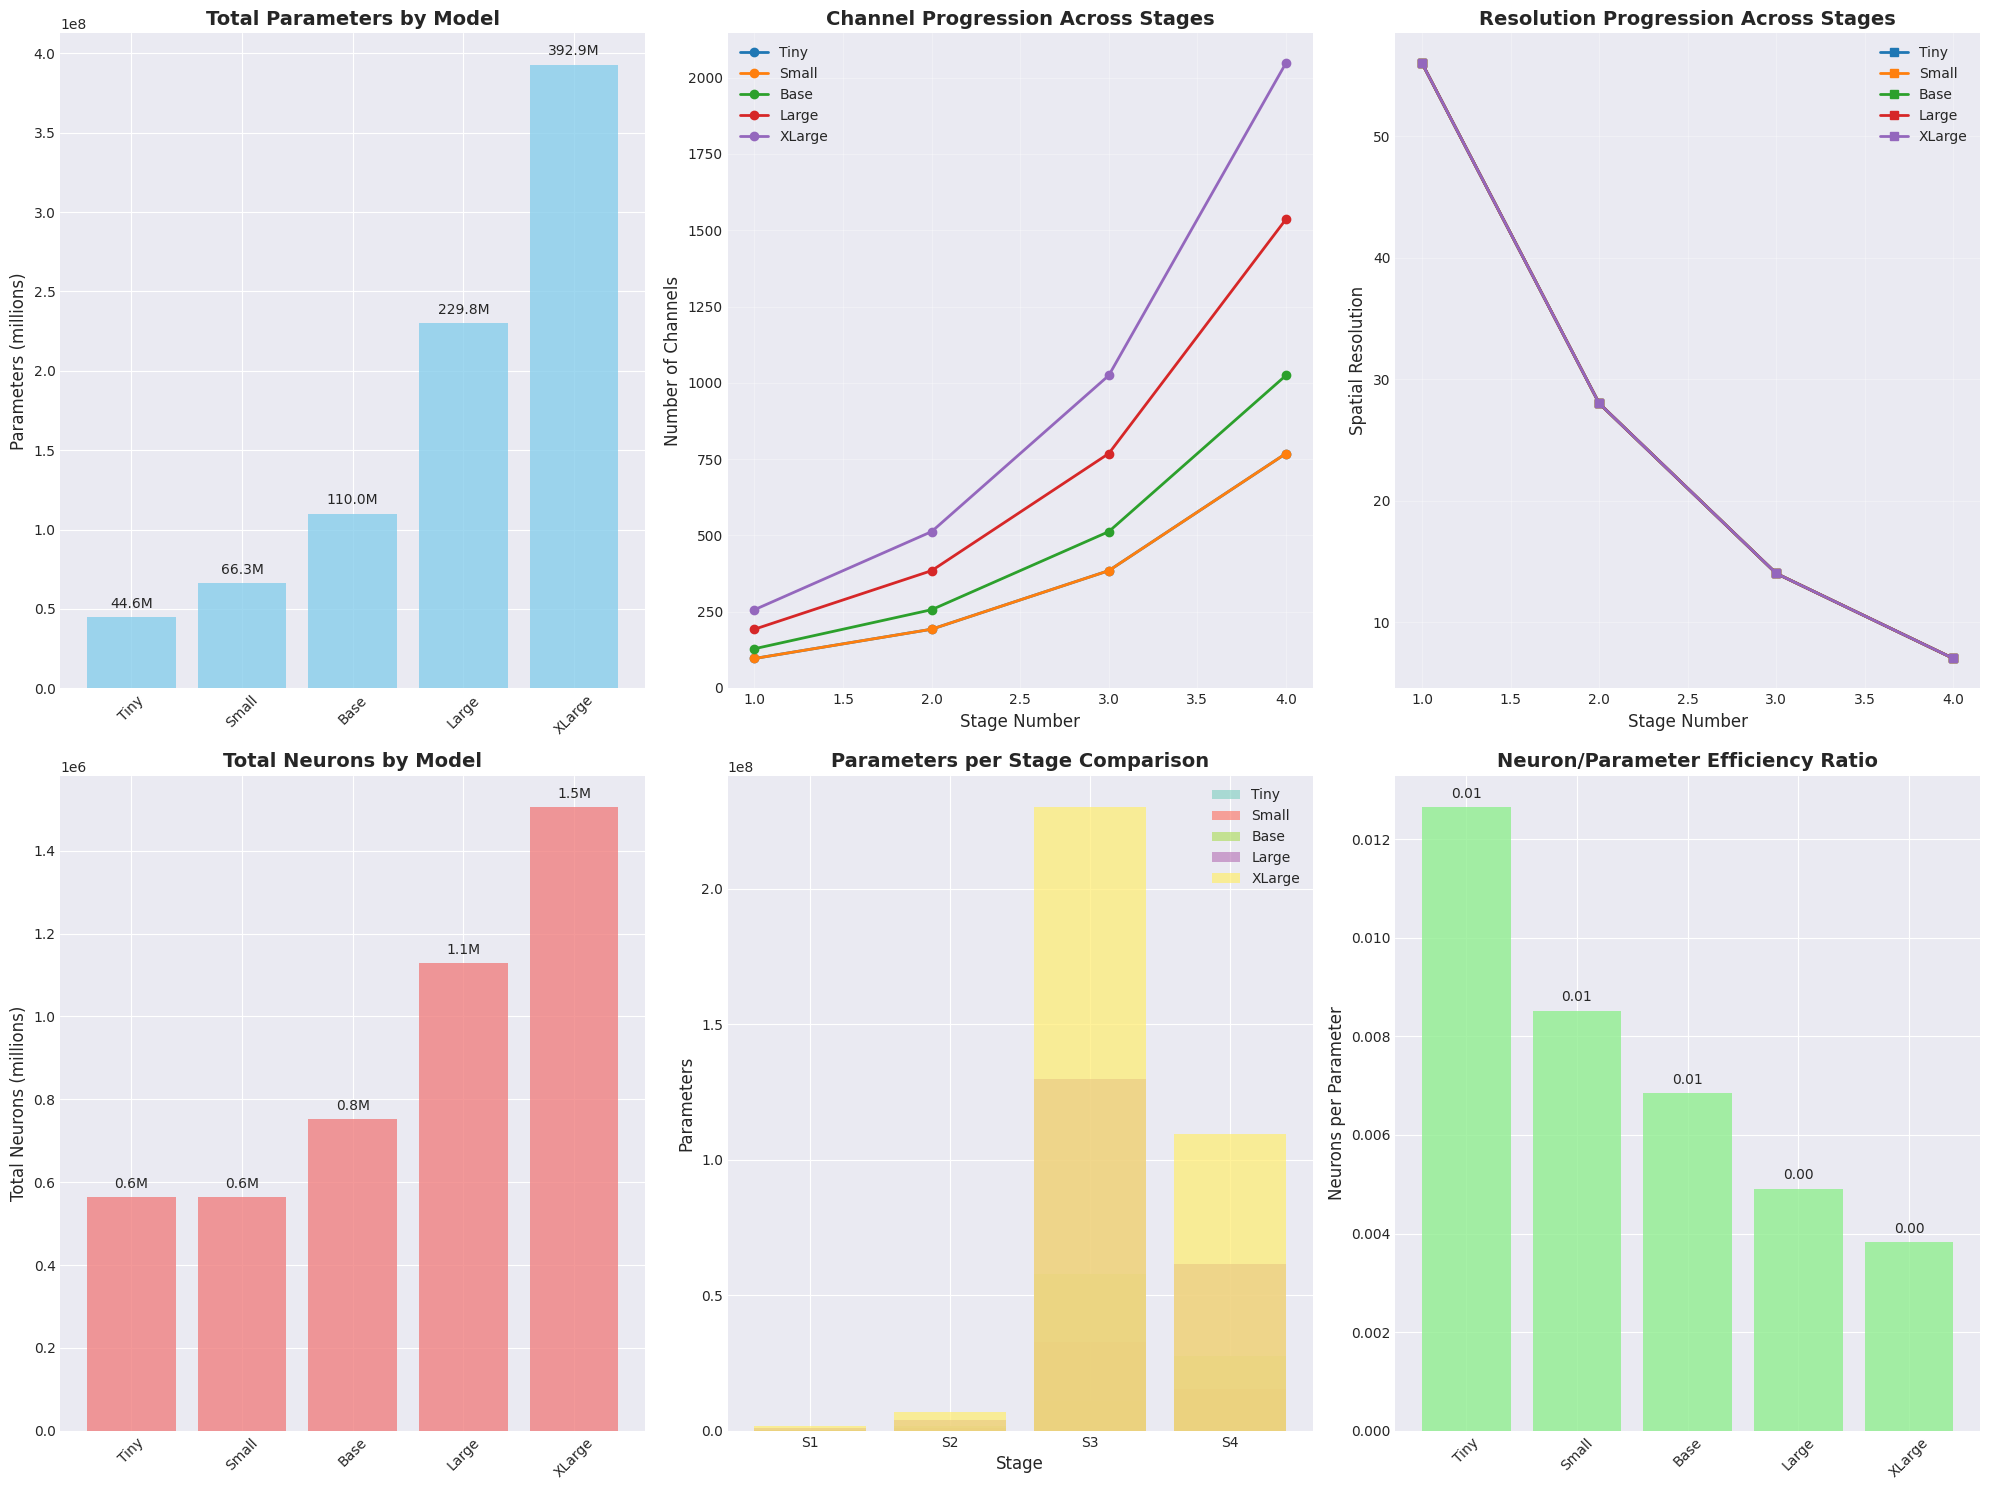

✓ Comprehensive visualizations created and saved!


In [15]:
# Create comprehensive visualizations
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(20, 15))

# 1. Total Parameters Comparison
plt.subplot(2, 3, 1)
model_names = [analysis['model_name'] for analysis in all_analyses.values()]
total_params = [analysis['total_params'] for analysis in all_analyses.values()]

bars = plt.bar(range(len(model_names)), total_params, color='skyblue', alpha=0.8)
plt.title('Total Parameters by Model', fontsize=14, fontweight='bold')
plt.ylabel('Parameters (millions)', fontsize=12)
plt.xticks(range(len(model_names)), [name.split('-')[1] for name in model_names], rotation=45)

# Add value labels on bars
for i, (bar, param) in enumerate(zip(bars, total_params)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(total_params)*0.01,
             f'{param/1e6:.1f}M', ha='center', va='bottom', fontsize=10)

# 2. Stage-wise Channel Progression
plt.subplot(2, 3, 2)
for model_name, analysis in all_analyses.items():
    stages = [s['stage_idx'] for s in analysis['stages']]
    channels = [s['channels'] for s in analysis['stages']]
    plt.plot(stages, channels, marker='o', linewidth=2, label=model_name.split('-')[1])

plt.title('Channel Progression Across Stages', fontsize=14, fontweight='bold')
plt.xlabel('Stage Number', fontsize=12)
plt.ylabel('Number of Channels', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Resolution Progression
plt.subplot(2, 3, 3)
for model_name, analysis in all_analyses.items():
    stages = [s['stage_idx'] for s in analysis['stages']]
    resolutions = [s['resolution'] for s in analysis['stages']]
    plt.plot(stages, resolutions, marker='s', linewidth=2, label=model_name.split('-')[1])

plt.title('Resolution Progression Across Stages', fontsize=14, fontweight='bold')
plt.xlabel('Stage Number', fontsize=12)
plt.ylabel('Spatial Resolution', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Total Neurons per Model
plt.subplot(2, 3, 4)
total_neurons = [sum(s['neurons'] for s in analysis['stages']) for analysis in all_analyses.values()]

bars = plt.bar(range(len(model_names)), total_neurons, color='lightcoral', alpha=0.8)
plt.title('Total Neurons by Model', fontsize=14, fontweight='bold')
plt.ylabel('Total Neurons (millions)', fontsize=12)
plt.xticks(range(len(model_names)), [name.split('-')[1] for name in model_names], rotation=45)

# Add value labels
for i, (bar, neuron) in enumerate(zip(bars, total_neurons)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(total_neurons)*0.01,
             f'{neuron/1e6:.1f}M', ha='center', va='bottom', fontsize=10)

# 5. Stage-wise Parameter Distribution
plt.subplot(2, 3, 5)
stage_data = []
model_labels = []
colors = plt.cm.Set3(np.linspace(0, 1, len(all_analyses)))

for i, (model_name, analysis) in enumerate(all_analyses.items()):
    stage_params = [s['parameters'] for s in analysis['stages']]
    stages = [f"S{s['stage_idx']}" for s in analysis['stages']]
    
    plt.bar(stages, stage_params, alpha=0.7, label=model_name.split('-')[1], color=colors[i])

plt.title('Parameters per Stage Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Stage', fontsize=12)
plt.ylabel('Parameters', fontsize=12)
plt.legend()

# 6. Efficiency Metrics (Parameters vs Neurons)
plt.subplot(2, 3, 6)
efficiency_ratios = []
model_labels = []

for model_name, analysis in all_analyses.items():
    total_params = analysis['total_params']
    total_neurons = sum(s['neurons'] for s in analysis['stages'])
    efficiency = total_neurons / total_params if total_params > 0 else 0
    efficiency_ratios.append(efficiency)
    model_labels.append(model_name.split('-')[1])

bars = plt.bar(range(len(model_labels)), efficiency_ratios, color='lightgreen', alpha=0.8)
plt.title('Neuron/Parameter Efficiency Ratio', fontsize=14, fontweight='bold')
plt.ylabel('Neurons per Parameter', fontsize=12)
plt.xticks(range(len(model_labels)), model_labels, rotation=45)

# Add value labels
for i, (bar, ratio) in enumerate(zip(bars, efficiency_ratios)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(efficiency_ratios)*0.01,
             f'{ratio:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('/home/wanglab/PyTorch/ConvNeXT/convnext_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comprehensive visualizations created and saved!")

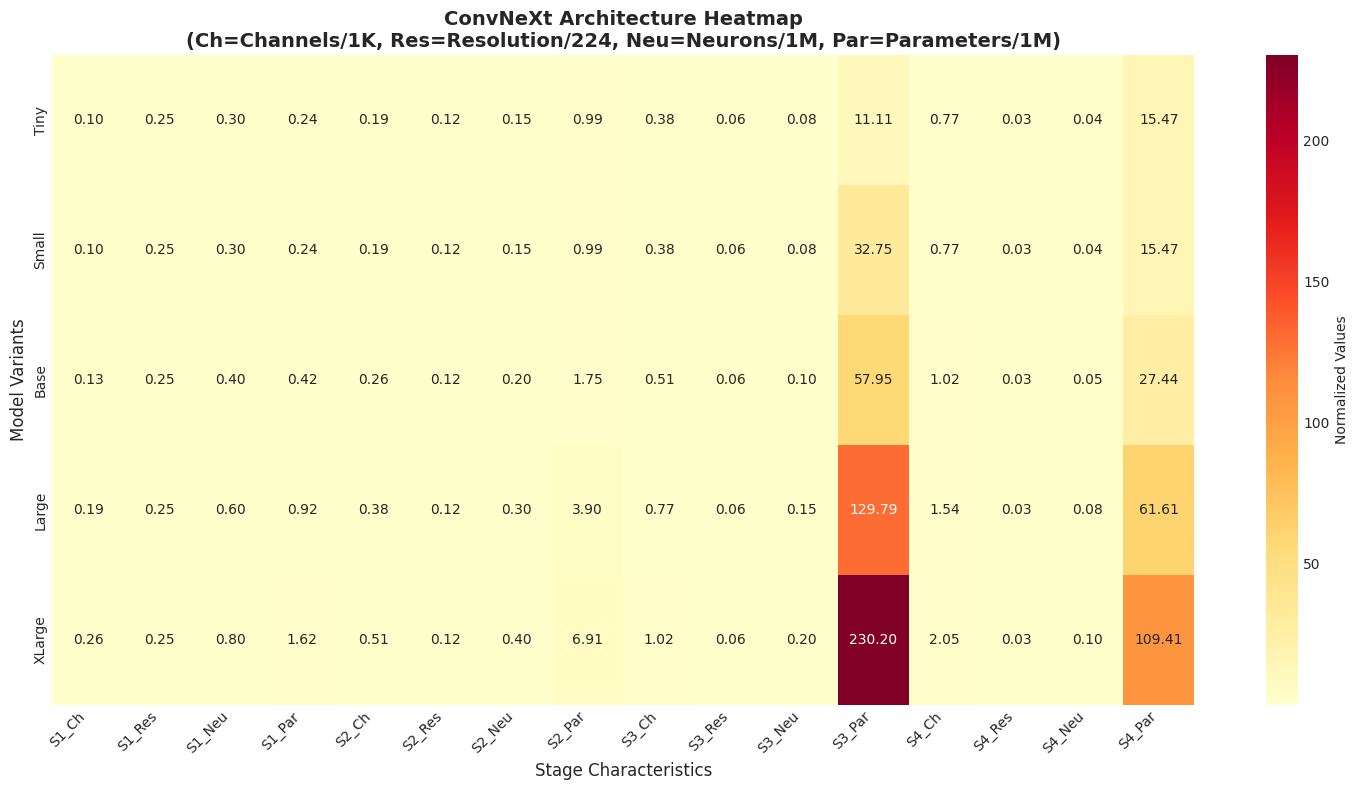

✓ Detailed heatmap visualization created!


In [16]:
# Additional detailed heatmap visualization
plt.figure(figsize=(15, 8))

# Create a heatmap showing stage characteristics
heatmap_data = []
stage_labels = []
model_labels = []

for model_name, analysis in all_analyses.items():
    model_labels.append(model_name.split('-')[1])
    row_data = []
    
    for stage in analysis['stages']:
        # Normalize values for better visualization
        normalized_channels = stage['channels'] / 1000  # Scale channels
        normalized_resolution = stage['resolution'] / 224  # Scale resolution
        normalized_neurons = stage['neurons'] / 1e6  # Scale neurons to millions
        normalized_params = stage['parameters'] / 1e6  # Scale parameters to millions
        
        row_data.extend([normalized_channels, normalized_resolution, 
                        normalized_neurons, normalized_params])
    
    heatmap_data.append(row_data)
    
    if not stage_labels:  # Only create labels once
        for stage in analysis['stages']:
            stage_labels.extend([
                f"S{stage['stage_idx']}_Ch", f"S{stage['stage_idx']}_Res",
                f"S{stage['stage_idx']}_Neu", f"S{stage['stage_idx']}_Par"
            ])

# Create heatmap
heatmap_array = np.array(heatmap_data)
sns.heatmap(heatmap_array, 
           xticklabels=stage_labels,
           yticklabels=model_labels,
           annot=True, 
           fmt='.2f',
           cmap='YlOrRd',
           cbar_kws={'label': 'Normalized Values'})

plt.title('ConvNeXt Architecture Heatmap\n(Ch=Channels/1K, Res=Resolution/224, Neu=Neurons/1M, Par=Parameters/1M)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Stage Characteristics', fontsize=12)
plt.ylabel('Model Variants', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/home/wanglab/PyTorch/ConvNeXT/convnext_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Detailed heatmap visualization created!")